# 4. Simulación numérica con Runge-Kutta de orden 4

**Objetivo:** resolver la ecuación diferencial $dT/dt = -k(T - T_{amb}(t))$ con el método RK4 y comparar la simulación con las mediciones reales.

In [4]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d

df = pd.read_csv(Path('datos_limpios.csv'))
df.head()

,muestra,tiempo_min,T_guadua,H_guadua,T_plastico,H_plastico,T_ambiente,H_ambiente
0,1,0,0.6,0.0,0.8,55.0,-2.4,10.0
1,2,1,24.1,55.0,25.5,60.0,20.1,63.0
2,3,2,24.3,55.0,25.9,60.0,20.1,63.0
3,4,3,24.2,55.0,25.1,60.0,20.1,63.0
4,5,4,24.4,55.0,25.2,60.0,20.0,63.0


## Parámetros y función RK4

Se estima $k$ desde los datos y se interpola la temperatura ambiente para evaluar el modelo en cualquier instante.

In [5]:
def estimar_k_local(temperatura, ambiente, dt=1.0):
    temperatura = np.asarray(temperatura, dtype=float)
    ambiente = np.asarray(ambiente, dtype=float)
    delta_ambiente = temperatura[:-1] - ambiente[:-1]
    delta_temperatura = temperatura[1:] - temperatura[:-1]
    mascara = np.abs(delta_ambiente) > 1e-6
    k_local = -delta_temperatura[mascara] / (dt * delta_ambiente[mascara])
    k_local = k_local[np.isfinite(k_local)]
    k_local = k_local[(k_local > 0) & (k_local < 0.1)]
    return k_local

k_guadua = float(np.mean(estimar_k_local(df['T_guadua'], df['T_ambiente'])))
k_plastico = float(np.mean(estimar_k_local(df['T_plastico'], df['T_ambiente'])))

t_data = df['tiempo_min'].to_numpy(dtype=float)
tamb_data = df['T_ambiente'].to_numpy(dtype=float)
tamb_func = interp1d(t_data, tamb_data, kind='linear', fill_value='extrapolate')

def rk4_step(T, t, dt, tamb_func, k):
    def f(temperatura, tiempo):
        return -k * (temperatura - float(tamb_func(tiempo)))

    k1 = f(T, t)
    k2 = f(T + 0.5 * dt * k1, t + 0.5 * dt)
    k3 = f(T + 0.5 * dt * k2, t + 0.5 * dt)
    k4 = f(T + dt * k3, t + dt)
    return T + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)

## Simulación y error

Se simula la evolución térmica para ambos materiales y se calcula el RMSE frente a las mediciones originales.

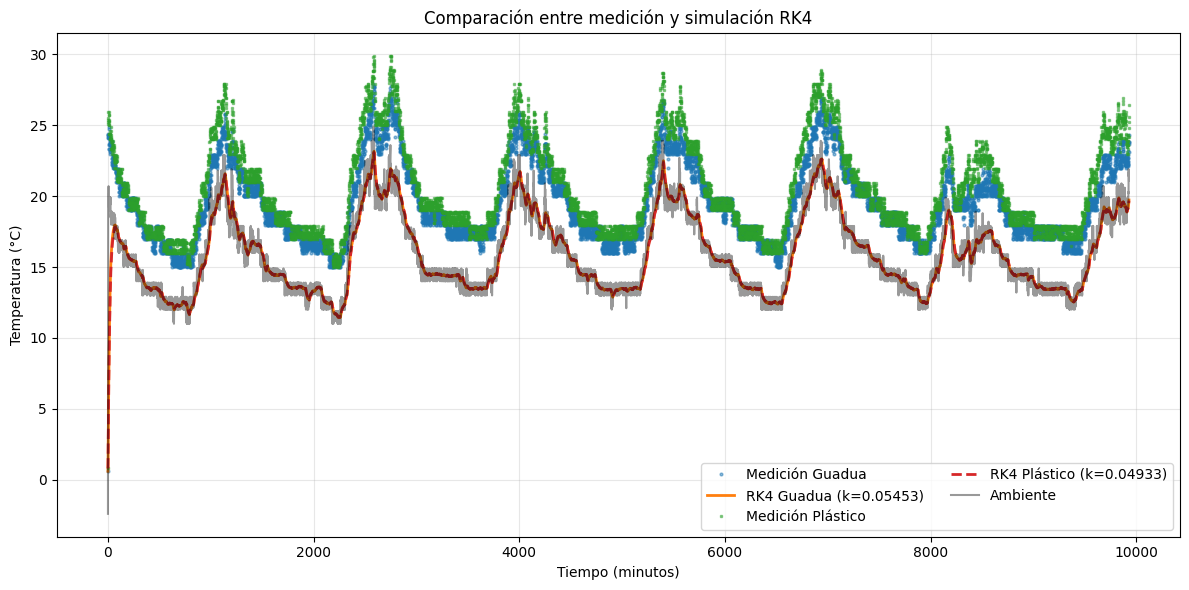

,Material,k (1/min),RMSE (°C)
0,Guadua,0.054529,3.729848
1,Plástico,0.049334,4.714153


In [6]:
dt = 1.0
t_sim = np.arange(t_data[0], t_data[-1] + dt, dt)

T_guadua_sim = np.zeros_like(t_sim, dtype=float)
T_plastico_sim = np.zeros_like(t_sim, dtype=float)
T_guadua_sim[0] = df['T_guadua'].iloc[0]
T_plastico_sim[0] = df['T_plastico'].iloc[0]

for i in range(len(t_sim) - 1):
    T_guadua_sim[i + 1] = rk4_step(T_guadua_sim[i], t_sim[i], dt, tamb_func, k_guadua)
    T_plastico_sim[i + 1] = rk4_step(T_plastico_sim[i], t_sim[i], dt, tamb_func, k_plastico)

f_guadua_sim = interp1d(t_sim, T_guadua_sim, kind='linear')
f_plastico_sim = interp1d(t_sim, T_plastico_sim, kind='linear')

T_guadua_pred = f_guadua_sim(t_data)
T_plastico_pred = f_plastico_sim(t_data)

rmse_guadua = float(np.sqrt(np.mean((df['T_guadua'] - T_guadua_pred) ** 2)))
rmse_plastico = float(np.sqrt(np.mean((df['T_plastico'] - T_plastico_pred) ** 2)))

plt.figure(figsize=(12, 6))
plt.plot(df['tiempo_min'], df['T_guadua'], 'o', markersize=2, alpha=0.5, label='Medición Guadua')
plt.plot(t_sim, T_guadua_sim, '-', linewidth=2, label=f'RK4 Guadua (k={k_guadua:.5f})')
plt.plot(df['tiempo_min'], df['T_plastico'], 's', markersize=2, alpha=0.5, label='Medición Plástico')
plt.plot(t_sim, T_plastico_sim, '--', linewidth=2, label=f'RK4 Plástico (k={k_plastico:.5f})')
plt.plot(df['tiempo_min'], df['T_ambiente'], color='black', alpha=0.4, label='Ambiente')
plt.xlabel('Tiempo (minutos)')
plt.ylabel('Temperatura (°C)')
plt.title('Comparación entre medición y simulación RK4')
plt.grid(True, alpha=0.3)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()

resumen = pd.DataFrame({
    'Material': ['Guadua', 'Plástico'],
    'k (1/min)': [k_guadua, k_plastico],
    'RMSE (°C)': [rmse_guadua, rmse_plastico]
}).round(6)

resumen